In [8]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import statsmodels.api as sm

1. Importing all necessary libraries and packages.

In [9]:
#loading dataset and description
pd.read_csv('regression.csv')
df = pd.read_csv('regression.csv')
df.head()
df.tail()
df.info()
df.dropna()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


2. The dataset is loaded and explored. Stating its full description and missing values.
   The dataset contains 4572 rows, four columns and all columns are floats in type. Sales range is from 31.20 to 364.08. Sales and Social media both contains 10 missing variable.
   
   

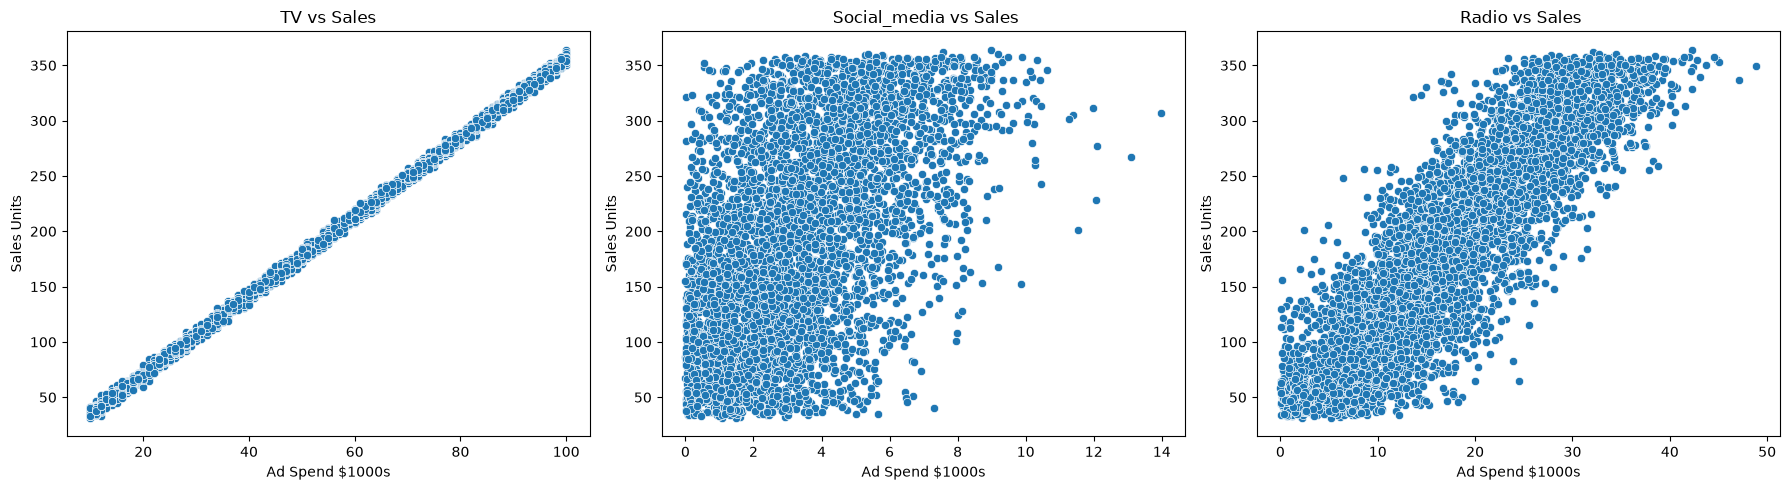

Social_Media    0.528906
Radio           0.869105
TV              0.999497
Sales           1.000000
Name: Sales, dtype: float64


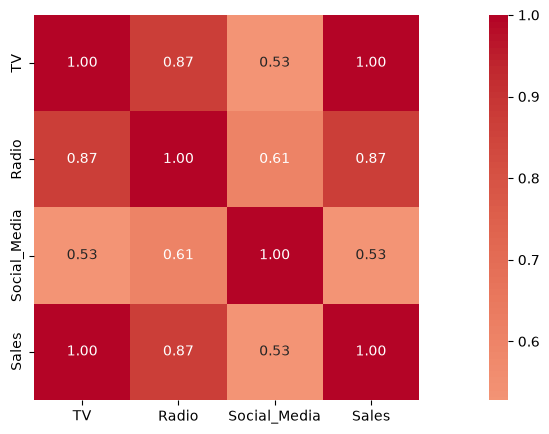

In [10]:
#performing scatterplots
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (18,5)
fig, axes = plt.subplots(1,3, figsize= (18,5))
sns.scatterplot(data=df, x='TV' , y = 'Sales', ax=axes[0])
sns.scatterplot(data=df, x='Social_Media' ,y ='Sales', ax=axes[1])
sns.scatterplot(data=df, x='Radio' , y= 'Sales' , ax =axes[2])

#setting titles for each graphs
axes[0].set_title  ('TV vs Sales')
axes[1].set_title (' Social_media vs Sales')
axes[2].set_title (' Radio vs Sales')
for ax in axes:
 ax.set_xlabel('Ad Spend $1000s')
 ax.set_ylabel('Sales Units')
plt.tight_layout()
plt.show()

#testing for correlation amidst the variable
corr = df[['TV', 'Radio','Social_Media', 'Sales']].corr()
sns.heatmap(corr,annot=True, cmap='coolwarm', center = 0  , fmt='.2f', square = True)


print(corr['Sales'].sort_values(ascending=True))



3.  Perform exploratory data analysis (EDA) with visualizations
     - Scatterplots is carried out on TV vs Sales , Radio vs Sales , Social_Media vs Sales to che k the whether linear or      curved and the result showed that Tv vs Sales is the most linear.
     - correlation heatmap is also carried out and it shows that Tv has the strongest linear relationship with sales at R = 1.00. Therefore, Tv will be use as the independent variable for simple linear regression.
    
   

In [2]:
# using TV as independent variable and Sales as dependent variable to get the OLS regression results.
import statsmodels.api as sm
df_clean = df[['TV' ,'Sales']].dropna()
X= df_clean['TV']
y =df_clean['Sales']

X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

NameError: name 'df' is not defined

4. Statistical results:
   R-squared = 0.999:this means that 99.9% of sales variation is explained by the TV spend.
   TV co-effiecient is positive and statistically significant,p less than 0.001
   F-statistic = 4.527e+06confrims model is highly significant

   Business translation:
    TV advertising has a near-perfect linear impact on Sales. The model assuptions hold based on diagnostic plots.
   Recommendation:
   I iwll recommend that majority of the allocation of the marketing budget should be to TV channel. Each additional unit spent on TV drives predictable increase in Sales.
    i will also consider testing Tv + Radio combination nect to capture the remaining 0.1% variation. 